# Protest theme classifier — run-6000 summary

One page on where the current model came from: the label taxonomy, how two
independent annotators compared, why we picked one, how training went, and what
it scored on the locked test set.

Figures are embedded rather than recomputed — they are the record, and the
source reports under `artifacts/reports/` are gitignored. Sources: `docs/model_runs.md`,
`artifacts/reports/test_locked_6000_flash_seed42.json`, `notebooks/compare_annotators.ipynb`.

In [1]:
from pathlib import Path
import json
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

# Validated categorical slots 1 and 2 (light mode). Colour follows the entity.
FLASH, V1 = '#2a78d6', '#eb6834'
INK, INK_2, SURFACE, GRID = '#0b0b0b', '#52514e', '#fcfcfb', '#d9d9d6'

## 1. The taxonomy

Taxonomy `2026-09-21-v3`, **23 classes**. Each event gets exactly one
`primary_label` for the substantive domain it concerns, plus an optional
`alternative_labels` holding at most one secondary domain when the note
genuinely supports a second reading.

What changed from `2026-09-20-v1` (21 classes):

| Change | Detail |
| --- | --- |
| renamed | `blm` → `racism`, widened beyond anti-Black racism |
| removed | `anti-government and anti-establishment` — classify the substantive domain, or `other` |
| added | `anti-fascism and extremism` |
| added | `crime, violence and victim justice` |
| added | `civil liberties and censorship` |

The decision rule, in order: resolve international scope first, then the stated
demand; when the demand is vague, fall back to the protesting group's role or
the affected institution; an explicit grievance overrides that fallback. `other`
only when no class fits **and** the fallback also fails.

`docs/prompts/annotation_prompt.md` is the annotator-facing contract;
`src/protest_classifier/taxonomy.py` is canonical. They are kept in sync.

## 2. Agreement between two annotators

Two independent runs over the same frozen manifests with a **byte-identical
prompt** (SHA-256 `19c2da75…8250`), differing only in model: DeepSeek-V4.1-Flash
(`deepseek-flash`) and DeepSeek-V4-Pro-0813 (`deepseek-v4-pro`).

- **strict** — the two primary labels are identical
- **lenient** — the `{primary, secondary}` sets share a label

Cohen's kappa is strict-only: kappa needs one categorical choice per rater.

In [2]:
agreement = pd.DataFrame([
    {'split': 'dev',         'n':  497, 'strict': 0.9074, 'lenient': 0.9437, 'kappa': 0.8968},
    {'split': 'test_locked', 'n':  840, 'strict': 0.9131, 'lenient': 0.9321, 'kappa': 0.9052},
    {'split': 'train_6000',  'n': 6000, 'strict': 0.9317, 'lenient': 0.9525, 'kappa': 0.9256},
])
agreement.style.hide(axis='index').format({
    'strict': '{:.2%}', 'lenient': '{:.2%}', 'kappa': '{:.4f}'})

split,n,strict,lenient,kappa
dev,497,90.74%,94.37%,0.8968
test_locked,840,91.31%,93.21%,0.9052
train_6000,6000,93.17%,95.25%,0.9256


Kappa 0.90–0.93 is "almost perfect" on the Landis–Koch scale, and sits just
below raw overlap — so the agreement is not an artefact of one dominant class.
ID coverage was exact on every split: nothing annotated by one and not the other.

## 3. Why flash

The ~545 strict disagreements on `train_6000` concentrate on one seam: the
`other` boundary. Both annotators err there, in **opposite directions**.

| | behaviour | count |
| --- | --- | --- |
| flash | under-uses the group/institution fallback, abstains to `other` | 69 rows pro assigned a domain |
| pro | over-uses it, reaching past the economic-loss and explicit-grievance guards | 137 rows flash assigned a domain |

Pro defers to `other` twice as often. Reading both slices by hand, neither is
uniformly better — roughly ten rows each way, the rest arguable. Flash was
chosen because it holds the environmental land-use boundary better (`climate and
environment` explicitly covers land use and opposition to harmful projects) and
violates fewer of the taxonomy's own guards: pro labelled trucker blockades over
"unfair economic competition" as `labor rights` against the rule that economic
loss alone does not establish wages, and filed anti-mosque protests under
`immigration` with no migration content in the note.

**The disagreements are not adjudicated.** Flash is the working set, not a
verified one. Both sets are archived under
`data/annotation_runs/archives/`.

## 4. Training

ModernBERT-base, 10 epochs max, lr 2e-5, batch 4 × accum 8 (effective 32),
max_length 256, patience 2, length grouping and gradient checkpointing on, BF16.
188 optimizer steps per epoch; 6,000 train rows (5 truncated notes), 497 dev.
Ran 92 minutes on an AMD Radeon 840M.

Checkpoint selection is on **dev macro-F1**, which weights all 23 classes
equally — the right target when the tail classes matter.

In [3]:
curve = pd.DataFrame({
    'epoch':    [1, 2, 3, 4, 5, 6, 7, 8, 9],
    'flash_f1': [0.4214, 0.6669, 0.6958, 0.7062, 0.7077, 0.7062, 0.7274, 0.7224, 0.7159],
    'flash_loss':[1.235, 0.683, 0.569, 0.693, 0.703, 0.761, 0.792, 0.796, 0.815],
    'v1_f1':    [0.4562, 0.5711, 0.6113, 0.6397, 0.6592, 0.6247, 0.6270, None, None],
    'v1_loss':  [1.239, 0.799, 0.825, 0.809, 0.914, 1.103, 1.093, None, None],
})
BEST_FLASH, BEST_V1 = 7, 5
curve.style.hide(axis='index').format(precision=4, na_rep='—')

epoch,flash_f1,flash_loss,v1_f1,v1_loss
1,0.4214,1.2350,0.4562,1.2390
2,0.6669,0.6830,0.5711,0.7990
3,0.6958,0.5690,0.6113,0.8250
4,0.7062,0.6930,0.6397,0.8090
5,0.7077,0.7030,0.6592,0.9140
6,0.7062,0.7610,0.6247,1.1030
7,0.7274,0.7920,0.6270,1.0930
8,0.7224,0.7960,—,—
9,0.7159,0.8150,—,—


findfont: Failed to find font weight medium, now using 400.


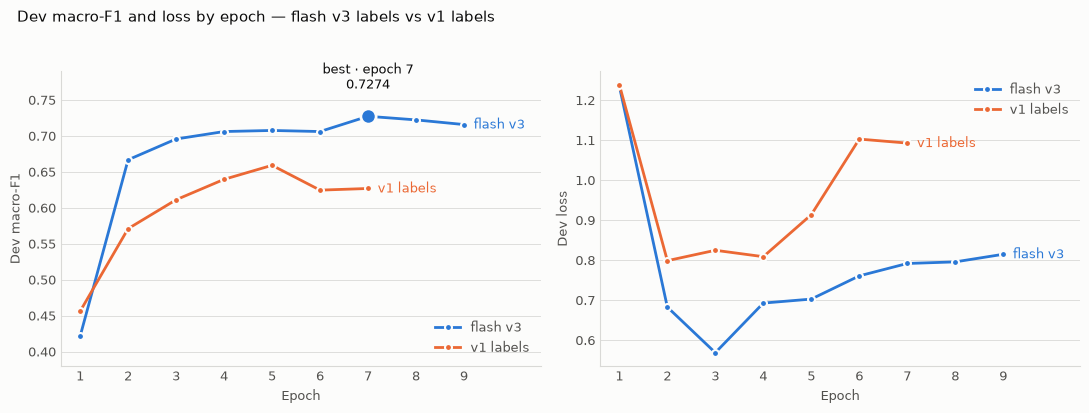

In [4]:
import matplotlib.pyplot as plt

def style(ax, ylabel):
    ax.set_xlabel('Epoch', color=INK_2, fontsize=9)
    ax.set_ylabel(ylabel, color=INK_2, fontsize=9)
    ax.grid(axis='y', color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=INK_2, labelsize=9, length=0)
    ax.set_xticks(curve.epoch)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4), facecolor=SURFACE)
for ax in (a1, a2):
    ax.set_facecolor(SURFACE)

# Two measures of different scale -> two panels, never a second y-axis.
for ax, (fcol, vcol), ylabel in (
    (a1, ('flash_f1', 'v1_f1'), 'Dev macro-F1'),
    (a2, ('flash_loss', 'v1_loss'), 'Dev loss'),
):
    for col, colour, label in ((fcol, FLASH, 'flash v3'), (vcol, V1, 'v1 labels')):
        s = curve[['epoch', col]].dropna()
        ax.plot(s.epoch, s[col], color=colour, linewidth=2, marker='o',
                markersize=5, markeredgecolor=SURFACE, markeredgewidth=1.5,
                label=label, zorder=3)
        # direct label at the line end (<=4 series, so label as well as legend)
        ax.annotate(label, (s.epoch.iloc[-1], s[col].iloc[-1]),
                    textcoords='offset points', xytext=(7, 0), va='center',
                    color=colour, fontsize=9, fontweight='medium')
    style(ax, ylabel)
    ax.set_xlim(0.6, 10.6)

# Ring the selected checkpoint on the panel that selected it.
best_y = float(curve.loc[curve.epoch == BEST_FLASH, 'flash_f1'].iloc[0])
a1.plot([BEST_FLASH], [best_y], marker='o', markersize=11, color=FLASH,
        markeredgecolor=SURFACE, markeredgewidth=2, zorder=4)
a1.annotate(f'best · epoch {BEST_FLASH}\n{best_y:.4f}', (BEST_FLASH, best_y),
            textcoords='offset points', xytext=(0, 20), ha='center',
            color=INK, fontsize=9)
a1.set_ylim(0.38, 0.79)
a1.legend(frameon=False, loc='lower right', fontsize=9, labelcolor=INK_2)
a2.legend(frameon=False, loc='upper right', fontsize=9, labelcolor=INK_2)

fig.suptitle('Dev macro-F1 and loss by epoch — flash v3 labels vs v1 labels',
             color=INK, fontsize=11, x=0.02, ha='left', y=1.02)
fig.tight_layout()
plt.show()

Loss bottomed at epoch 3 and rose from there while macro-F1 kept improving to
epoch 7 — the model grew overconfident on common classes while still learning
rare ones. Accuracy actually peaked at epoch 8 (0.8672), but selection is on
macro-F1, so **epoch 7 was saved**. Early stopping fired at epoch 9.

Both runs peaked on the same architecture and schedule (flash at 7, v1 at 5),
so the flash lead is a label-quality difference rather than a luckier stop.

**Selected model:** `artifacts/models/new_classifier/run-6000/seed-42/best/`
(md5 `ba1d7b19bc0351fee06b440ce46f2dc1`) — epoch 7, dev macro-F1 **0.7274**,
dev accuracy **0.8652**. The previous v1-label model was preserved at
`artifacts/models/new_classifier/run-6000/seed-42-v1-labels/` before this run overwrote it.

## 5. Locked test

840 rows, evaluated **once**, via `load_locked_test()` — ID coverage and
`note_hash` validated against `data/manifests/test_locked.csv`. Each model is
scored against its own annotator's gold, so these are three targets, not one
benchmark.

In [5]:
test = pd.DataFrame([
    {'model': 'classifier v2', 'classes': 21, 'strict': 0.8595, 'lenient': 0.8833, 'macro_f1': 0.8174},
    {'model': 'v1 labels',     'classes': 21, 'strict': 0.8500, 'lenient': 0.8857, 'macro_f1': 0.8170},
    {'model': 'flash v3',      'classes': 23, 'strict': 0.8917, 'lenient': 0.9071, 'macro_f1': 0.8647},
]).assign(lenient_gain=lambda d: (d.lenient - d.strict).round(4))
test.style.hide(axis='index').format({
    'strict': '{:.2%}', 'lenient': '{:.2%}', 'macro_f1': '{:.4f}', 'lenient_gain': '{:+.2%}'})

model,classes,strict,lenient,macro_f1,lenient_gain
classifier v2,21,85.95%,88.33%,0.8174,+2.38%
v1 labels,21,85.00%,88.57%,0.8170,+3.57%
flash v3,23,89.17%,90.71%,0.8647,+1.54%


## 6. Where it goes wrong

91 errors, concentrated on the `other` boundary — the same seam the two
annotators disagreed about.

In [6]:
report = ROOT / 'artifacts/reports/test_locked_6000_flash_seed42.json'
if not report.exists():
    print(f'{report} not found (artifacts/reports/ is gitignored) — rerun the locked-test evaluation.')
else:
    import numpy as np
    r = json.loads(report.read_text())
    weak = (pd.DataFrame([{'class': k, **{m: v[m] for m in ('f1', 'precision', 'recall')},
                           'n': v['support']} for k, v in r['per_class'].items()])
            .sort_values('f1').head(6))
    display(weak.style.hide(axis='index').format(precision=3))

    labels, cm = r['labels'], np.array(r['confusion_matrix'])
    pairs = [{'n': int(cm[i][j]), 'gold': labels[i], 'predicted': labels[j]}
             for i in range(len(labels)) for j in range(len(labels))
             if i != j and cm[i][j] > 0]
    display(pd.DataFrame(sorted(pairs, key=lambda p: -p['n'])[:6])
            .style.hide(axis='index'))

class,f1,precision,recall,n
other,0.715,0.667,0.772,57
housing and rents,0.750,0.750,0.750,12
civil liberties and censorship,0.750,0.667,0.857,14
war and foreign policy,0.759,0.880,0.667,33
culture,0.778,0.875,0.700,10
cost of living and inflation,0.786,0.786,0.786,14


n,gold,predicted
6,climate and environment,other
4,war and foreign policy,other
4,"democratic institutions, corruption, elections, and reforms",other
3,labor rights and wages,healthcare
3,labor rights and wages,pandemic
3,war and foreign policy,ukraine-russia war


`other` is the weakest class (F1 0.715, precision 0.667) and appears in five of
the eight largest confusion pairs, in both directions: `climate and environment
→ other` (6), `war and foreign policy → other` (4), `democratic institutions →
other` (4), and `other → anti-fascism and extremism` (3).

Two smaller patterns: `labor rights → healthcare` and `labor rights → pandemic`
(3 each), likely health-sector strikes during COVID where the model reads the
setting rather than the demand; and `war and foreign policy → ukraine-russia war`
(3), a boundary the taxonomy draws on whether that conflict is *central*.

The model inherited the ambiguity in its labels. Sharpening `other` in the
prompt — that it requires the group/institution fallback to fail too — is the
highest-value next change, ahead of more training data.